### Preparing dataset for Netflix Content Dashboard

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Load and inspect dataset

In [31]:
df = pd.read_csv('data/netflix_titles.csv')

In [32]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


- Checking unique values for some columns

In [34]:
# show type
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [35]:
# country
df['country'].value_counts()

country
United States                                    2818
India                                             972
United Kingdom                                    419
Japan                                             245
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64

In [36]:
# rating
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

- In the rating column, 74 min, 84 min, 66 min are irrelevent data (noise)
- We shall inspect those rows

In [37]:
df[df['rating'].str.contains('min', na=False)] # na ignores value rows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5541,s5542,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies,"Louis C.K. muses on religion, eternal love, gi..."
5794,s5795,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies,Emmy-winning comedy writer Louis C.K. brings h...
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies,The comic puts his trademark hilarious/thought...


- Let's replace them using **mode**

In [38]:
mask = df['rating'].str.contains('min', na=False)

df.loc[mask, 'rating'] = df['rating'].mode()

In [39]:
df['rating'].value_counts().tail()

rating
NR          80
G           41
TV-Y7-FV     6
NC-17        3
UR           3
Name: count, dtype: int64

In [40]:
# listed in
df['listed_in'].value_counts()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Action & Adventure, Cult Movies                       1
Action & Adventure, Comedies, Music & Musicals        1
Classic Movies, Horror Movies, Thrillers              1
Children & Family Movies, Classic Movies, Dramas      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 514, dtype: int64

- This column is quite useful, so we will feature engineer this column

In [41]:
# Creates separate columns for each genre found in 'listed_in'
genre_features = df['listed_in'].str.get_dummies(sep=', ')
df = pd.concat([df.drop('listed_in', axis=1), genre_features], axis=1)

In [42]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'description',
       'Action & Adventure', 'Anime Features', 'Anime Series',
       'British TV Shows', 'Children & Family Movies', 'Classic & Cult TV',
       'Classic Movies', 'Comedies', 'Crime TV Shows', 'Cult Movies',
       'Documentaries', 'Docuseries', 'Dramas', 'Faith & Spirituality',
       'Horror Movies', 'Independent Movies', 'International Movies',
       'International TV Shows', 'Kids' TV', 'Korean TV Shows', 'LGBTQ Movies',
       'Movies', 'Music & Musicals', 'Reality TV', 'Romantic Movies',
       'Romantic TV Shows', 'Sci-Fi & Fantasy', 'Science & Nature TV',
       'Spanish-Language TV Shows', 'Sports Movies', 'Stand-Up Comedy',
       'Stand-Up Comedy & Talk Shows', 'TV Action & Adventure', 'TV Comedies',
       'TV Dramas', 'TV Horror', 'TV Mysteries', 'TV Sci-Fi & Fantasy',
       'TV Shows', 'TV Thrillers', 'Teen TV Shows', 'Thrillers'],

### Performing data cleaning

In [43]:
# Remove unnecessary columns
df = df.drop(columns=['show_id', 'cast', 'description'])

- Handling missing values

In [44]:
df.isnull().sum().sort_values(ascending=False)

director                        2634
country                          831
date_added                        10
rating                             7
duration                           3
type                               0
title                              0
release_year                       0
Action & Adventure                 0
Anime Features                     0
Anime Series                       0
British TV Shows                   0
Children & Family Movies           0
Classic & Cult TV                  0
Classic Movies                     0
Comedies                           0
Crime TV Shows                     0
Cult Movies                        0
Documentaries                      0
Docuseries                         0
Dramas                             0
Faith & Spirituality               0
Horror Movies                      0
Independent Movies                 0
International Movies               0
International TV Shows             0
Kids' TV                           0
K

In [45]:
# Fill missing directors and countries with 'Unknown'
df['director'] = df['director'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [46]:
df.isnull().sum().sort_values(ascending=False)

date_added                      10
rating                           7
duration                         3
type                             0
title                            0
director                         0
release_year                     0
country                          0
Action & Adventure               0
Anime Features                   0
Anime Series                     0
British TV Shows                 0
Children & Family Movies         0
Classic & Cult TV                0
Classic Movies                   0
Comedies                         0
Crime TV Shows                   0
Cult Movies                      0
Documentaries                    0
Docuseries                       0
Dramas                           0
Faith & Spirituality             0
Horror Movies                    0
Independent Movies               0
International Movies             0
International TV Shows           0
Kids' TV                         0
Korean TV Shows                  0
LGBTQ Movies        

In [47]:
# Remove missing 'rating', 'date added' and 'duration' rows
df = df.dropna(subset=['rating', 'date_added', 'duration'])

----
### Visualizing dataset 

In [48]:
df.columns

Index(['type', 'title', 'director', 'country', 'date_added', 'release_year',
       'rating', 'duration', 'Action & Adventure', 'Anime Features',
       'Anime Series', 'British TV Shows', 'Children & Family Movies',
       'Classic & Cult TV', 'Classic Movies', 'Comedies', 'Crime TV Shows',
       'Cult Movies', 'Documentaries', 'Docuseries', 'Dramas',
       'Faith & Spirituality', 'Horror Movies', 'Independent Movies',
       'International Movies', 'International TV Shows', 'Kids' TV',
       'Korean TV Shows', 'LGBTQ Movies', 'Movies', 'Music & Musicals',
       'Reality TV', 'Romantic Movies', 'Romantic TV Shows',
       'Sci-Fi & Fantasy', 'Science & Nature TV', 'Spanish-Language TV Shows',
       'Sports Movies', 'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows',
       'TV Action & Adventure', 'TV Comedies', 'TV Dramas', 'TV Horror',
       'TV Mysteries', 'TV Sci-Fi & Fantasy', 'TV Shows', 'TV Thrillers',
       'Teen TV Shows', 'Thrillers'],
      dtype='object')

- Content added overtime

<Axes: xlabel='date_added', ylabel='count'>

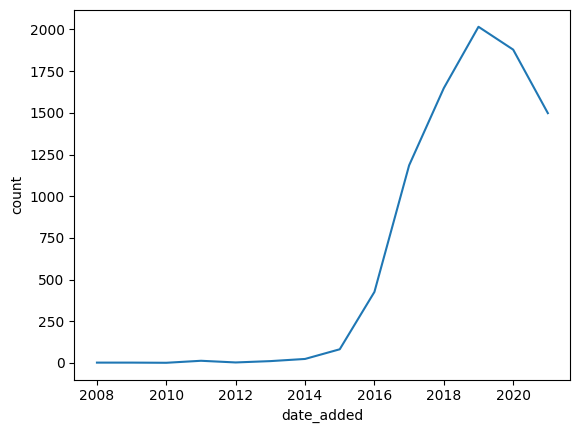

In [49]:
# Clean and convert to datetime
date_series = pd.to_datetime(df['date_added'].str.strip())

yearly_count = date_series.dt.year.value_counts()

yearly_count = yearly_count.sort_index() # 2008, 2009,... 2021

# Plot
sns.lineplot(x = yearly_count.index, y=yearly_count)

- Titles by type (Movies / TV Shows)

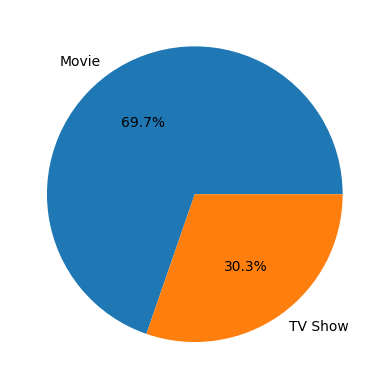

In [50]:
# Aggregate the data
title_type = df['type'].value_counts()

plt.pie(title_type, labels=title_type.index, autopct="%1.1f%%");


- Top genres

Text(0, 0.5, 'Genre')

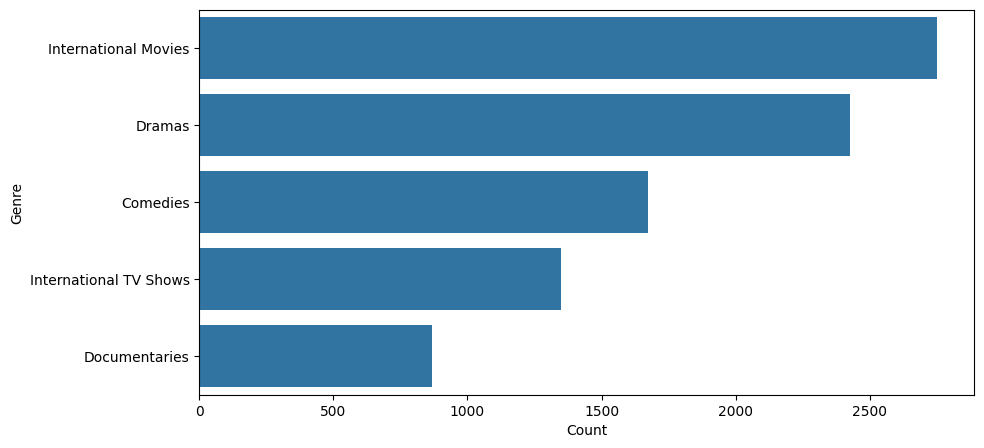

In [51]:
# Extract the genre columns (dummy encoded), and sum the values for each
genre_cols = genre_features.columns

top_genres = df[genre_cols].sum().sort_values(ascending=False).head(5)

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(x=top_genres, y=top_genres.index)

plt.xlabel('Count')
plt.ylabel('Genre')



- Content by rating

Text(0, 0.5, 'Rating')

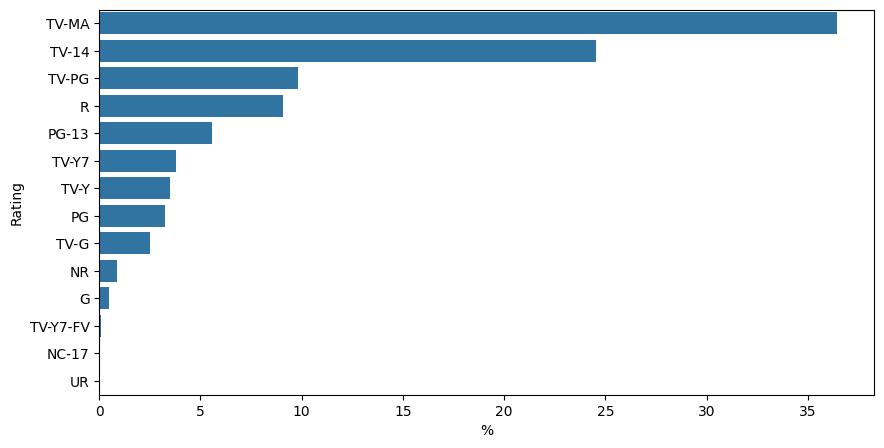

In [52]:
# Aggregate rating using %

rating_per = df['rating'].value_counts(normalize = True) * 100

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(x=rating_per, y=rating_per.index)

plt.xlabel('%')
plt.ylabel('Rating')

- Content origin by country


#### Data Transformation Table

| Title | Original Country | After .split(', ') | After .explode() |
|---|---|---|---|
| Movie A | "USA, India" | ['USA', 'India'] | USA |
| | | | India |
| Movie B | "Japan" | ['Japan'] | Japan |
| Movie C | "UK, France" | ['UK', 'France'] | UK |
| | | | France |

------------------------------
#### The Code with Documentation

# The "Major Line" broken down:country_counts = (
    df['country']
    .str.split(', ')  # Step 2: Convert "A, B" -> ['A', 'B']
    .explode()        # Step 3: Turn 1 row with a list into 2 separate rows
    .value_counts()   # Step 4: Count each occurrence across all rows
)



In [53]:
clean_country_count = (df['country'].
                str.split(','). # 1. Split strings by comma and space
                explode(). # 2. Explode the lists into individual rows
                str.strip(). # 3. Clean the string to remove white space (if any)
                value_counts(). # 4. Then count the values!
                reset_index())  

clean_country_count.columns = ['country', 'count'] # Rename columns

top_countries = clean_country_count.head(15)

fig = px.scatter(
    top_countries,
    x='country',
    y='count',
    size='count',
    color='count',
    hover_name='country',
    text='country',
    color_continuous_scale='Blues',
    size_max=60
)

fig.update_traces(textposition='top center')

fig.update_layout(
    template='plotly_dark'
)

fig.show()

----
### Save dataset

In [54]:
df.to_csv('data/clean_netflix_titles.csv', index=False)

In [55]:
clean_country_count

,country,count
0,United States,3681
1,India,1046
2,Unknown,829
3,United Kingdom,805
4,Canada,445
...,...,...
119,Sudan,1
120,Panama,1
121,Uganda,1
122,East Germany,1


In [56]:
yearly_count

date_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

In [57]:
title_type

type
Movie      6126
TV Show    2664
Name: count, dtype: int64